In [1]:
import sys
sys.path.append('../../dataloaders/3W')
sys.path.append('../../../3W')
import os
os.environ['path3W'] = '../../../'
import numpy as np
import pandas as pd

In [2]:
from loader import Loader3W
import importlib
importlib.reload(sys.modules['loader'])
import toolkit
importlib.reload(sys.modules['toolkit'])
ld = Loader3W()

In [ ]:
#ld.get_ids_from_wells_with_event_type([8])
#ld.load_stats()
#ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
#ld.save_stats()

In [3]:
ld.load_stats()
dg = ld.preprocess()

In [52]:
from diffusion.ts_diffusion2 import TSDiffusion
importlib.reload(sys.modules['diffusion.ts_diffusion2'])
ts_diffusion = TSDiffusion(
    in_channels=17,
    latent_dim=256,
    model_dim=256,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000
    )


In [ ]:
import torch
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
ts_diffusion.train3W(
    window_size=15,
    batch_size=2000,
    epochs=1,
)

Starting epoch 1/1 - dataset 1/9 - Partial Validation Loss: 0.999932


KeyboardInterrupt: 

In [53]:
ts_diffusion = ts_diffusion.load('ts_diffusion_3w_ep20.pt',in_channels=17,
    latent_dim=256,
    model_dim=256,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000)
#ts_diffusion.save('ts_diffusion_3w_ep20.pt')

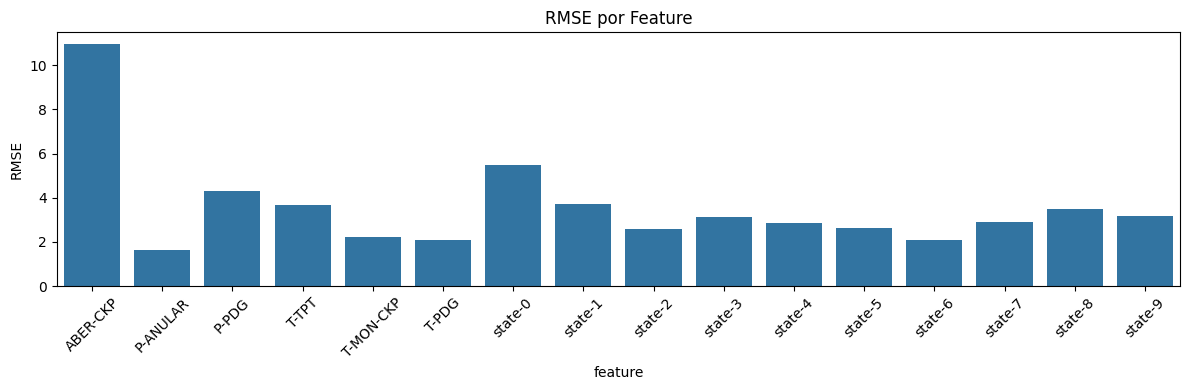

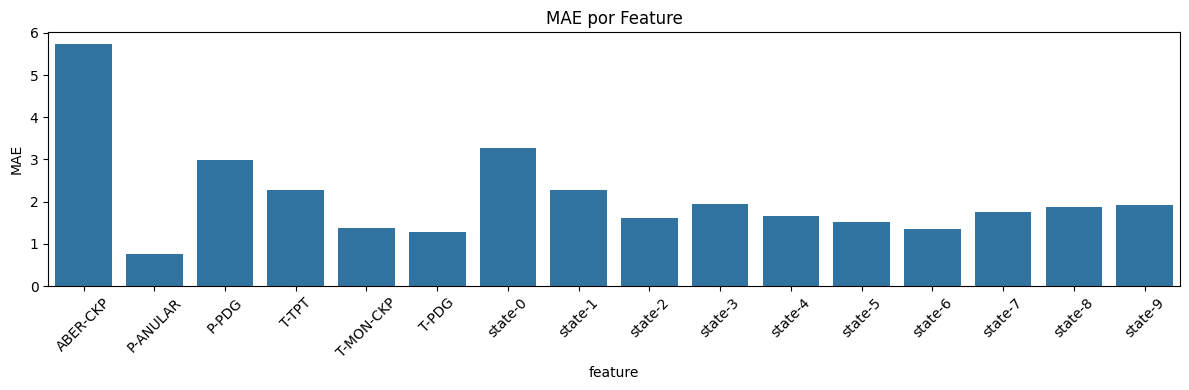

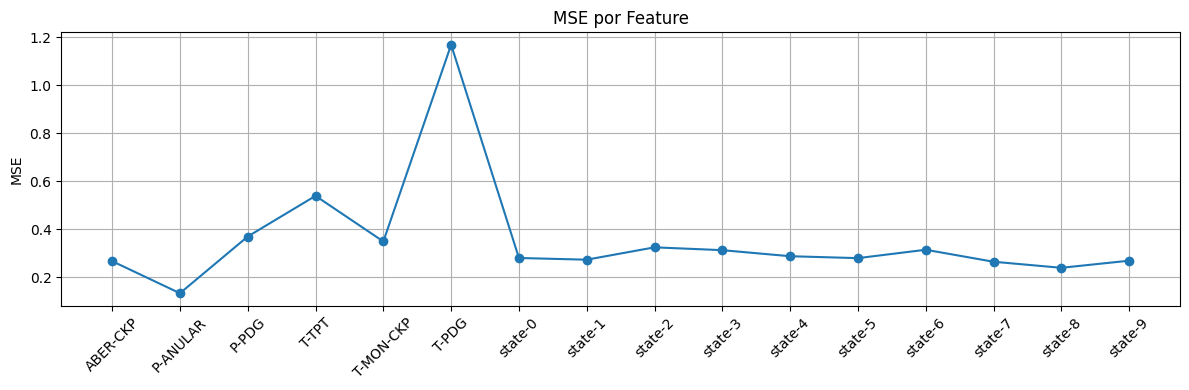

In [54]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=2,
    window_size=15,
    batch_size=256,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=50
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)